## 1. Import Dependencies

Install required packages before running:
```
pip install -r requirements.txt
```


In [ ]:
# data handling
import numpy as np
import pandas as pd
import fasttext
# visualization
import matplotlib.pyplot as plt
# nltk for text preprocessing
import nltk
from nltk.corpus import stopwords
# sklearn for model evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
# re 
import re

## 2. Loading Dataset
#### Note: **make sure the encoding is set to latin1 not the default utf-8**


In [91]:
df = pd.read_csv("../data/spam.csv", encoding="latin-1")
df.head()


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [92]:
print("Number of samples:", df.shape[0])
print("----------------------------------------------------------")
print(df["v1"].value_counts(normalize=True) * 100)
print("----------------------------------------------------------")
df.info()


Number of samples: 5572
----------------------------------------------------------
v1
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64
----------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


## 3. Preparing the data

In [93]:
df=df[["v1","v2"]]
df.rename(columns={"v1":"label","v2":"message"},inplace=True)
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 4. Data Visualization

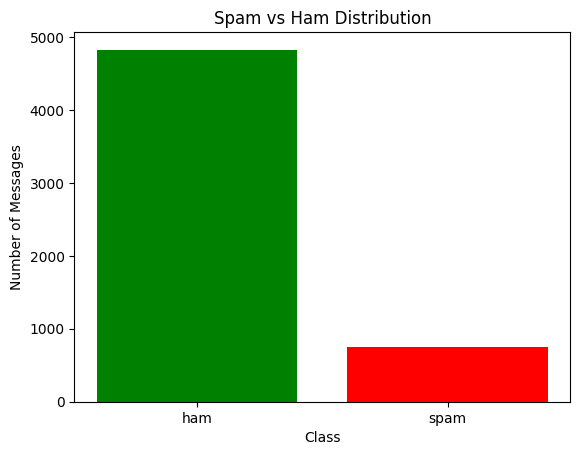

In [94]:


counts = df['label'].value_counts()

plt.figure()
plt.bar(counts.index, counts.values, color=['green', 'red'])
plt.title("Spam vs Ham Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Messages")
plt.show()

## 5. Data Pre-Processing

In [95]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [96]:
stopwords_set=set(stopwords.words("english"))

def preprocess_text(text):
    text = text.lower()  # lowercase
    text = re.sub(r'\d+', '', text)  # remove numbers
    text = re.sub(r'http\S+|www\S+', '', text)  # remove links
    text = re.sub(r'[^\w\s]', '', text)  # remove punctuation
    text=" ".join(word for word in text.split() if word not in stopwords_set)
    text = text.strip()
    return text


In [97]:
df['final_clean_text'] = df['message'].apply(preprocess_text)
df.head()

,label,message,final_clean_text
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,ham,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


## 6 Splitting Data
 

In [98]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

## 7 Converting to FastText Format 

In [ ]:
def save_fasttext_format(data, filename):
    with open(filename, "w", encoding="utf-8") as f:
        for _, row in data.iterrows():
            f.write(f"__label__{row['label']} {row['final_clean_text']}\n")
save_fasttext_format(train_df, "train.txt")
save_fasttext_format(test_df, "test.txt")

## 8. Train the model  

In [ ]:
model = fasttext.train_supervised(
    input="train.txt",
    epoch=25,
    lr=1.0,
    wordNgrams=2
)

## 9. Evaluation

In [ ]:
# quick evaluation on test set
result = model.test("test.txt")

print("Samples:", result[0])
print("Precision:", result[1])
print("Recall:", result[2])

In [ ]:
y_true = []
y_pred = []

with open("test.txt", "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
            
        parts = line.split(" ", 1)
        if len(parts) == 2:
            label, text = parts

            true_label = label.replace("__label__", "")
            predicted_label = model.predict(text)[0][0].replace("__label__", "")

            y_true.append(true_label)
            y_pred.append(predicted_label)
        else:
            # Handle lines that don't have both a label and text
            print(f"Skipping line (missing text or label): {line}")

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, pos_label='spam'))
print("Recall:", recall_score(y_true, y_pred, pos_label='spam'))
print("F1-score:", f1_score(y_true, y_pred, pos_label='spam'))

In [ ]:
cm = confusion_matrix(y_true, y_pred, labels=['ham', 'spam'])
print(cm)

In [ ]:
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ['Ham', 'Spam'])
plt.yticks([0, 1], ['Ham', 'Spam'])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.colorbar()
plt.show()

## 5.2 Tokenization 